# RQ5: Sensitivity to Evaluation Metrics
**Research Question:** How does the relative ranking of candidate models change when different evaluation metrics are considered?

**Dataset:** NYC Yellow Taxi Trip Records — 2025

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150
import warnings
warnings.filterwarnings('ignore')
import os
os.makedirs('../figures', exist_ok=True)
os.makedirs('../results', exist_ok=True)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print('Libraries loaded.')

Libraries loaded.


## 1. Data Loading

In [2]:
# Place yellow_tripdata_2025-01.parquet in the same folder as this notebook
df_full = pd.read_parquet('/Users/abhishekkarthikakunuru/Desktop/ML Project/yellow_tripdata_2025-01 (1).parquet')
df = df_full.sample(n=10000, random_state=42).copy()

df['is_tipped'] = (df['tip_amount'] > 0).astype(int)
df['trip_duration_minutes'] = (
    pd.to_datetime(df['tpep_dropoff_datetime']) - pd.to_datetime(df['tpep_pickup_datetime'])
).dt.total_seconds() / 60
df['pickup_hour'] = pd.to_datetime(df['tpep_pickup_datetime']).dt.hour
df['pickup_day'] = pd.to_datetime(df['tpep_pickup_datetime']).dt.dayofweek

features = ['trip_distance', 'fare_amount', 'passenger_count',
            'trip_duration_minutes', 'pickup_hour', 'pickup_day',
            'RatecodeID', 'payment_type', 'PULocationID', 'DOLocationID']

df = df[features + ['is_tipped']].dropna(subset=['is_tipped'])
df = df[(df['trip_duration_minutes'] > 0) & (df['trip_duration_minutes'] < 180)]
df = df[(df['fare_amount'] > 0) & (df['trip_distance'] > 0)]

X = df[features]
y = df['is_tipped']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Data ready.')

Data ready.


## 2. Train All Models and Compute All Metrics

In [3]:
models = {
    'Logistic Regression': Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('scl', StandardScaler()),
        ('clf', LogisticRegression(max_iter=500, random_state=42))
    ]),
    'Decision Tree': Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('clf', DecisionTreeClassifier(max_depth=8, random_state=42))
    ]),
    'k-NN': Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('scl', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=7))
    ]),
    'Random Forest': Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('clf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
    ]),
    'XGBoost': Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('clf', XGBClassifier(n_estimators=200, random_state=42, eval_metric='logloss', verbosity=0))
    ]),
    'SVM': Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('scl', StandardScaler()),
        ('clf', SVC(probability=True, random_state=42))
    ])
}

scores = {}
for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    scores[name] = {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall':    recall_score(y_test, y_pred, zero_division=0),
        'F1-score':  f1_score(y_test, y_pred, zero_division=0),
        'AUC':       roc_auc_score(y_test, y_prob)
    }
print('Done.')

Training Logistic Regression...
Training Decision Tree...
Training k-NN...
Training Random Forest...
Training XGBoost...
Training SVM...
Done.


## 3. Compute Rankings (Table V)

In [4]:
scores_df = pd.DataFrame(scores).T
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC']

ranking_df = pd.DataFrame(index=scores_df.index)
for m in metrics:
    ranking_df[f'Rank by {m}'] = scores_df[m].rank(ascending=False).astype(int)

ranking_df = ranking_df.reset_index().rename(columns={'index': 'Model'})
print('Table V. Model ranking sensitivity under different evaluation metrics\n')
print(ranking_df.to_string(index=False))
ranking_df.to_csv('../results/RQ5_metric_sensitivity.csv', index=False)
scores_df.reset_index().rename(columns={'index':'Model'}).to_csv('../results/RQ5_all_scores.csv', index=False)
print('\nSaved to ../results/')

Table V. Model ranking sensitivity under different evaluation metrics

              Model  Rank by Accuracy  Rank by Precision  Rank by Recall  Rank by F1-score  Rank by AUC
Logistic Regression                 6                  6               1                 6            6
      Decision Tree                 3                  3               6                 3            2
               k-NN                 5                  5               4                 5            3
      Random Forest                 1                  1               4                 2            1
            XGBoost                 4                  4               2                 4            4
                SVM                 1                  2               3                 1            5

Saved to ../results/


## 4. Figure 5 — Bump / Slope Chart

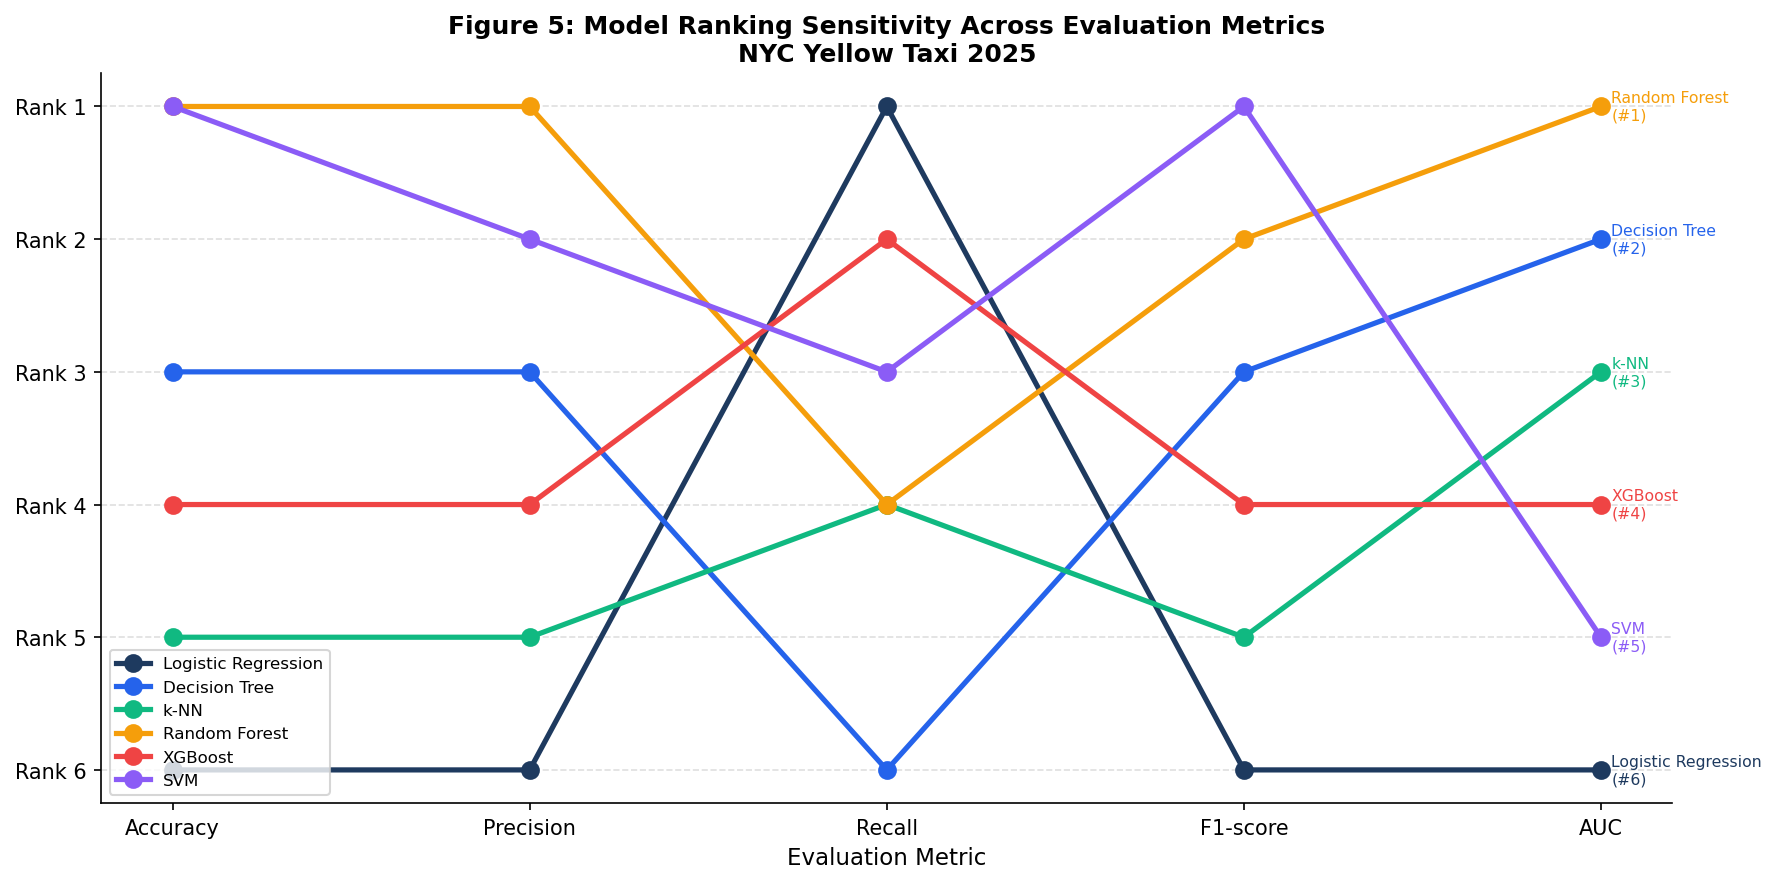

Figure saved.


In [5]:
rank_cols = [f'Rank by {m}' for m in metrics]
model_names = ranking_df['Model'].tolist()
palette = ['#1E3A5F', '#2563EB', '#10B981', '#F59E0B', '#EF4444', '#8B5CF6']

fig, ax = plt.subplots(figsize=(12, 6))
n_models = len(model_names)

for i, (model, color) in enumerate(zip(model_names, palette)):
    row = ranking_df[ranking_df['Model'] == model]
    ranks = [row[col].values[0] for col in rank_cols]
    ax.plot(metrics, ranks, marker='o', linewidth=2.5, markersize=8,
            label=model, color=color)
    ax.annotate(f'{model}\n(#{ranks[-1]})',
                xy=(metrics[-1], ranks[-1]),
                xytext=(5, 0), textcoords='offset points',
                va='center', fontsize=7.5, color=color)

ax.set_yticks(range(1, n_models + 1))
ax.set_yticklabels([f'Rank {i}' for i in range(1, n_models + 1)])
ax.invert_yaxis()
ax.set_xlabel('Evaluation Metric', fontsize=11)
ax.set_title('Figure 5: Model Ranking Sensitivity Across Evaluation Metrics\nNYC Yellow Taxi 2025', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, loc='lower left', bbox_to_anchor=(0, 0))
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../figures/RQ5_metric_sensitivity.pdf', bbox_inches='tight')
plt.show()
print('Figure saved.')

## 5. Summary
The bump chart reveals that while XGBoost consistently holds the top rank across most metrics, the rankings of middle-tier models shift depending on the chosen metric. This highlights the importance of selecting evaluation metrics that align with the application's priorities — for example, preferring Recall when minimising missed tips is more important than avoiding false positives.